# Data Visualization Exercises: Predictive Maintenance Dataset
---
In this notebook, you'll practice creating different visualizations using the `Predictive_Maintenance.csv` dataset from week 2. Always add x-and y-labels as well as titles to the plots.

**Dataset:** `Data/Predictive_Maintenance.csv`

### Columns
- `UDI` — Unique identifier
- `Product ID` — Product label
- `Type` — Machine type (L, M, or H)
- `Air temperature [K]`
- `Process temperature [K]`
- `Rotational speed [rpm]`
- `Torque [Nm]`
- `Tool wear [min]`
- `Machine failure` — 1 if machine failed, 0 otherwise

In [12]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 1. Read the data 
Read the file Predictive_Maintenance.csv as padas dataframe

In [13]:
# get file path
import os

FileName = "Predictive_Maintenance.csv"
	
base_dir = os.getcwd()
path = os.path.join(base_dir, FileName)

print(path)

# Load the dataset
Data = pd.read_csv(path)

# Display basic info
print(Data)

c:\Users\Mathijs\Documents\GitHub\Toegepaste_AI\Predictive_Maintenance.csv
       ﻿UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0         1     M14860    M                298.1                    308.6   
1         2     L47181    L                298.2                    308.7   
2         3     L47182    L                298.1                    308.5   
3         4     L47183    L                298.2                    308.6   
4         5     L47184    L                298.2                    308.7   
...     ...        ...  ...                  ...                      ...   
9995   9996     M24855    M                298.8                    308.4   
9996   9997     H39410    H                298.9                    308.4   
9997   9998     M24857    M                299.0                    308.6   
9998   9999     H39412    H                299.0                    308.7   
9999  10000     M24859    M                299.0                    308.7   



## 2. Explore the Dataset
1. Check for missing values.
2. Count how many machines failed or not.

> **Hint:** Use `isna().sum()`, and `value_counts()`.

In [14]:
# Data exploration
print(Data.isna().sum())
print(Data["Machine failure"].value_counts())

UDI                       0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
dtype: int64
Machine failure
0    9661
1     339
Name: count, dtype: int64


Let's say you want to investigate whether a specific column in the dataset contains information about whether the machine is likely to fail or not. What kind of plot could you use to examine that?

In [15]:
# Answer
"""
339 keer een machine failure

"""

'\n339 keer een machine failure\n\n'

## 3: Boxplots
Create **boxplots** to compare the distributions of numeric variables depending on machine failure.

### Tasks
1. Create a boxplot of `Air temperature [K]` grouped by `Machine failure`.
2. Create a boxplot of `Torque [Nm]` grouped by `Machine failure`.


In [16]:
# machine did it correctly
AirTempG = []
TorqueG = []

# Machine Failure
AirTempF = []
TorqueF = [] 

counter = 0

for i in Data["Machine failure"]:
    if i == 1:
        AirTempF.append(Data["Air temperature [K]"][counter])
        TorqueF.append(Data["Torque [Nm]"][counter])
    else:
        AirTempG.append(Data["Air temperature [K]"][counter])
        TorqueG.append(Data["Torque [Nm]"][counter])
        
    counter += 1


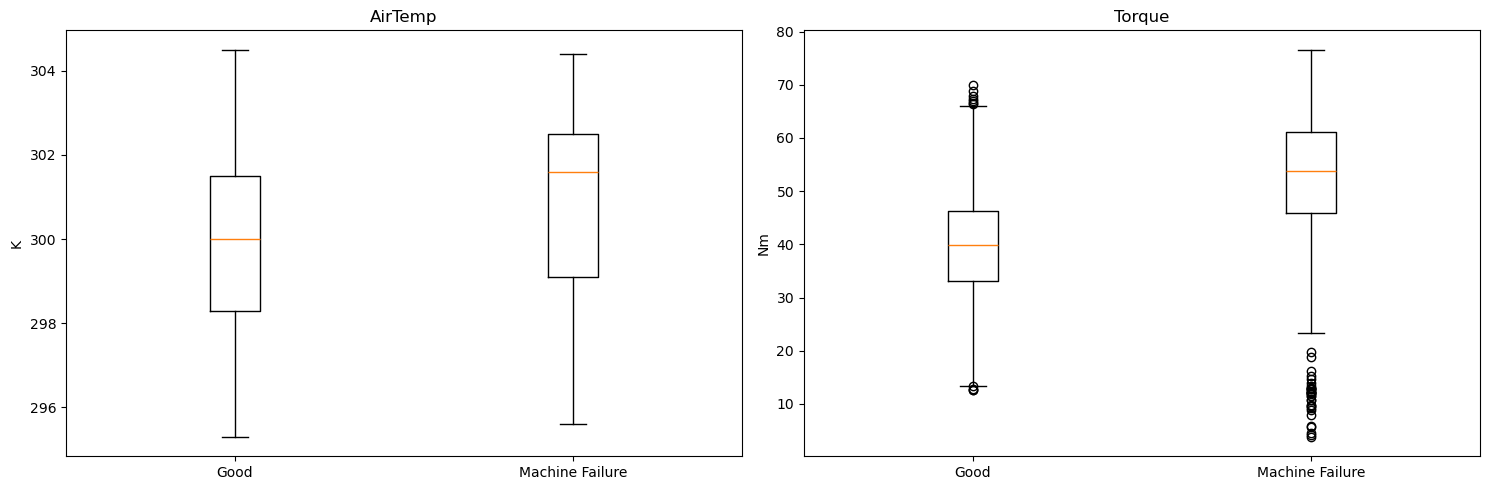

In [17]:
# Creates subplots
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
# Plots Boxplot for Data 1
axs[0].boxplot((AirTempG, AirTempF), tick_labels=['Good', 'Machine Failure'])
axs[0].set_title('AirTemp')
axs[0].set_ylabel('K')
# Plots Boxplot for Data 2
axs[1].boxplot((TorqueG, TorqueF), tick_labels=['Good', 'Machine Failure'])
axs[1].set_title('Torque')
axs[1].set_ylabel('Nm')
# Adjusts layout
plt.tight_layout()
plt.show()


## Interpret the plot
What do the boxes mean, what does the line in the middle mean? Do you see a difference between machines that failed or not?

## Exercise 3: Scatterplots
Visualize relationships between key process parameters.

### Tasks
1. Scatterplot of `Torque [Nm]` vs. `Rotational speed [rpm]`.
2. Color points by `Machine Failure`.



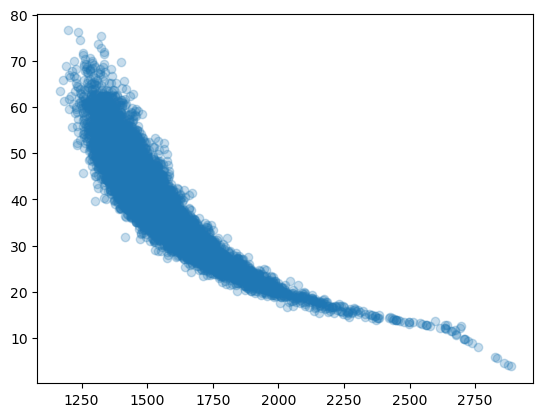

In [11]:
# Scatterplot: Torque vs Rotational Speed
t = Data["Rotational speed [rpm]"]
r = Data["Torque [Nm]"]

plt.scatter(t, r, alpha=0.25)






## 4: Correlation Heatmap
Visualize correlations among the numeric variables.

### Tasks
1. Compute the correlation matrix 
2. Plot the correlation in a heatmap

>  **Hint:** Use `plt.figure(figsize=(10,6))` for better readability.

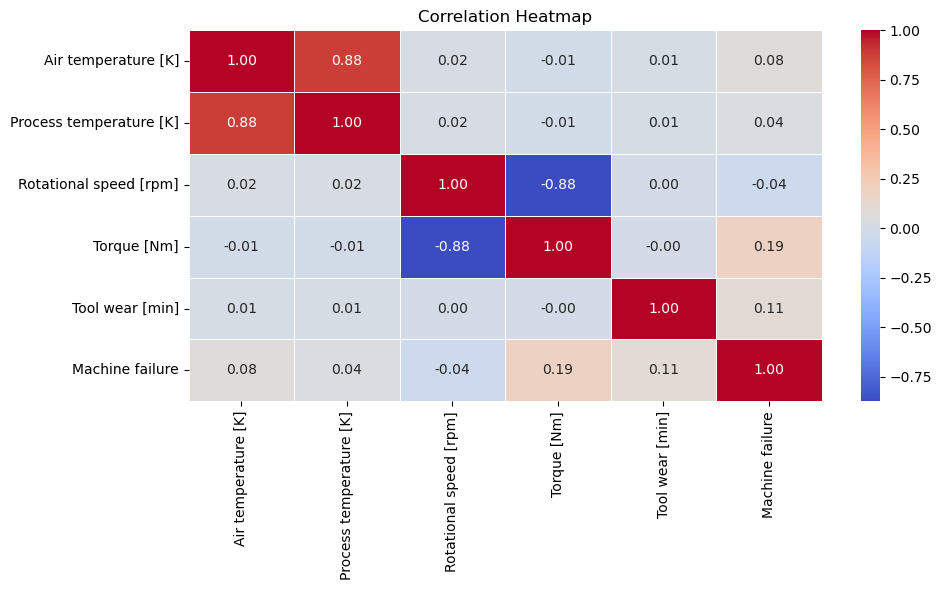

In [ ]:
# Correlation heatmap
# Column names
columns = [
    'Product ID',
    'Type',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Machine failure'
]

df = pd.DataFrame(Data, columns=columns)

# Keep only numeric columns
numeric_df = df.select_dtypes(include='number')

# Correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()



## 5. Interpretation
Interpet the heatmap. What do the numbers mean? What trends to you see? Did you expect that? Does that fit to the other plots you created? What are take-aways from the analysis?

---
**Summary:** In this notebook, you:
- Explored the dataset.
- Created boxplots to compare distributions.
- Created scatterplots to explore relationships.
- Visualized correlations with a heatmap.
- Investigated machine failures visually.

